In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import json
import torch

from src.utils import *

# Collapse probability with bimodal Gaussian mixture student

In the following we load the data used to produce the mode collapse probability grid plot for gaussian mixture student.

For each value of ($t_0$, $\beta_i$) there are 100 different runs. For each run, we only need the value of the overlap $s$ at the end of training.
$s=1$ indicates mode collapse. $s=-1$ indicates correct learning.

Hyperparameters values are $d=512$, $R=3$, $w_*=0.8$.

In [ ]:
#loading the data
exp_name = 'bimodalgrid512/'

res = pd.read_csv('data/'+exp_name+'final_s.csv', index_col=0)
res = pd.concat([res, pd.read_csv('data/'+exp_name+'final_s1.csv', index_col=0)])
res['beta_i'] = np.round(res['beta_i'].values, 5)
res

,exp,beta_i,t0,s
0,0,0.00011,100.0,0.892615
1,1,0.00011,100.0,0.909435
2,2,0.00011,100.0,0.920094
3,3,0.00011,100.0,0.915999
4,4,0.00011,100.0,-0.914352
...,...,...,...,...
3188,6395,0.35136,800.0,0.993158
3189,6396,0.35136,800.0,0.993026
3190,6397,0.35136,800.0,0.993080
3191,6398,0.35136,800.0,0.993404


In [7]:
np.unique(res['beta_i'].values)

array([1.1000e-04, 3.5000e-04, 1.1100e-03, 3.5100e-03, 1.1110e-02,
       3.5140e-02, 1.1111e-01, 3.5136e-01])

In [ ]:
# Computing fraction of mode collapsed run for each (t0, beta_i)
temp = res.loc[:, ['beta_i', 't0']].copy()
temp['prob'] = np.round(res.loc[:, 's'] > 0)
prob_collapse = temp.groupby(['beta_i', 't0']).mean()
prob_collapse

prob
beta_i  t0             
0.00011 100.0  0.880000
        200.0  0.850000
        300.0  0.710000
        400.0  0.540000
        500.0  0.360000
...                 ...
0.35136 400.0  0.878788
        500.0  0.870000
        600.0  0.870000
        700.0  0.860000
        800.0  0.858586

[64 rows x 1 columns]

In [17]:
# Prepare data using a pivot to ensure the grid is correctly aligned
prob_collapse = prob_collapse.reset_index()
bimodal_prob_pivot = prob_collapse.pivot(index='beta_i', columns='t0', values='prob')

betai_values = bimodal_prob_pivot.index
t0_values = bimodal_prob_pivot.columns
prob_matrix = bimodal_prob_pivot.values

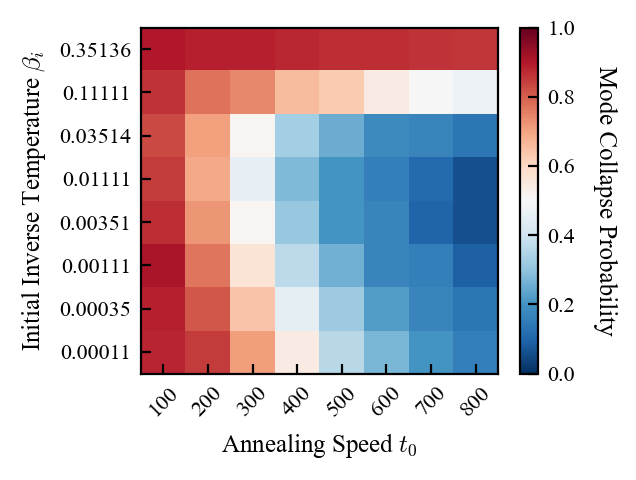

In [16]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",       # Computer Modern for math
    "font.size": 10,                # Main text size
    "axes.labelsize": 9,           # Axis labels
    "xtick.labelsize": 8,           # Tick labels
    "ytick.labelsize": 8,           # Tick labels
    "legend.fontsize": 8,           # Legend
    "figure.titlesize": 10,
    "xtick.direction": "in",        # Professional touch: ticks point inward
    "ytick.direction": "in",
    "axes.linewidth": 0.8,          # Thinner, cleaner spines
    "figure.dpi": 300               # High resolution for review
})

# 2. Plotting
fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=200)

im = ax.imshow(prob_matrix, origin='lower', aspect='auto', cmap='RdBu_r', vmin=0, vmax=1)# cmap : 'magma' or 'RdBu_r'

# Set ticks locations
ax.set_xticks(np.arange(len(t0_values)))
ax.set_yticks(np.arange(len(betai_values)))
ax.set_xticklabels([f"{int(v)}" for v in t0_values], rotation=45)
ax.set_yticklabels([f"{v:.5f}" for v in betai_values])

ax.set_xlabel(r'Annealing Speed $t_0$')
ax.set_ylabel(r'Initial Inverse Temperature $\beta_i$')

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Mode Collapse Probability', rotation=270, labelpad=15)

plt.tight_layout()

#plt.savefig('figures/grid_collapse_prob_icml.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Theoretical collapse probability

We implement the integral $I(\beta_i, t_0)$ and the theoretical mode collapse probability estimate $p(\beta_i, t_0)$.

In [25]:
from scipy.special import erf, erfinv

alpha=0.608
def I(R, beta_i, t0): return R/np.sqrt(2*np.pi) * 2*t0/np.log(beta_i)* min((np.sqrt(beta_i) - np.sqrt(alpha)/R), 0)

def p_collapse(R, beta_i, t0, eps, dim):
    z = np.sqrt(dim/2)*2*eps*np.exp(-I(R, beta_i, t0))
    return erf(z/np.sqrt(2))

# The following function returns the annealing time t0 needed to achieve mode collapse probability p given an initial temperature beta_i
def p_collapse_inv(p, R, beta_i, eps, dim):
    z = np.sqrt(2)*erfinv(p)
    I = - np.log(z/(np.sqrt(dim/2)*2*eps))
    return I/(R/np.sqrt(2*np.pi) * 2/np.log(beta_i)*(np.sqrt(beta_i) - np.sqrt(alpha)/R))

In [22]:
# Setting the hyperparameters value
dim = 512
radius = 3
w_star = 0.8
lr = 5e-2
eps = np.abs(np.log((1-w_star)/w_star)/2/radius**2)
print(fr'$\epsilon = {eps}$')

$\epsilon = 0.07701635339554949$


### 0.5 mode collapse iso-probability line

Adding the theoretical 0.5 mode collapse iso-probability line to the grid plot

In [26]:
#t_list = np.linspace(100,800,20)
beta_list = np.logspace(-4, -0.3, 100)/radius**2

#p_collapse_values = np.array([[p_collapse(radius, beta0, 5e-2*t0, eps, dim) for t0 in t_list] for beta0 in beta_list])
inv_t_list = np.array([p_collapse_inv(0.5, radius, beta, eps, dim) for beta in beta_list])

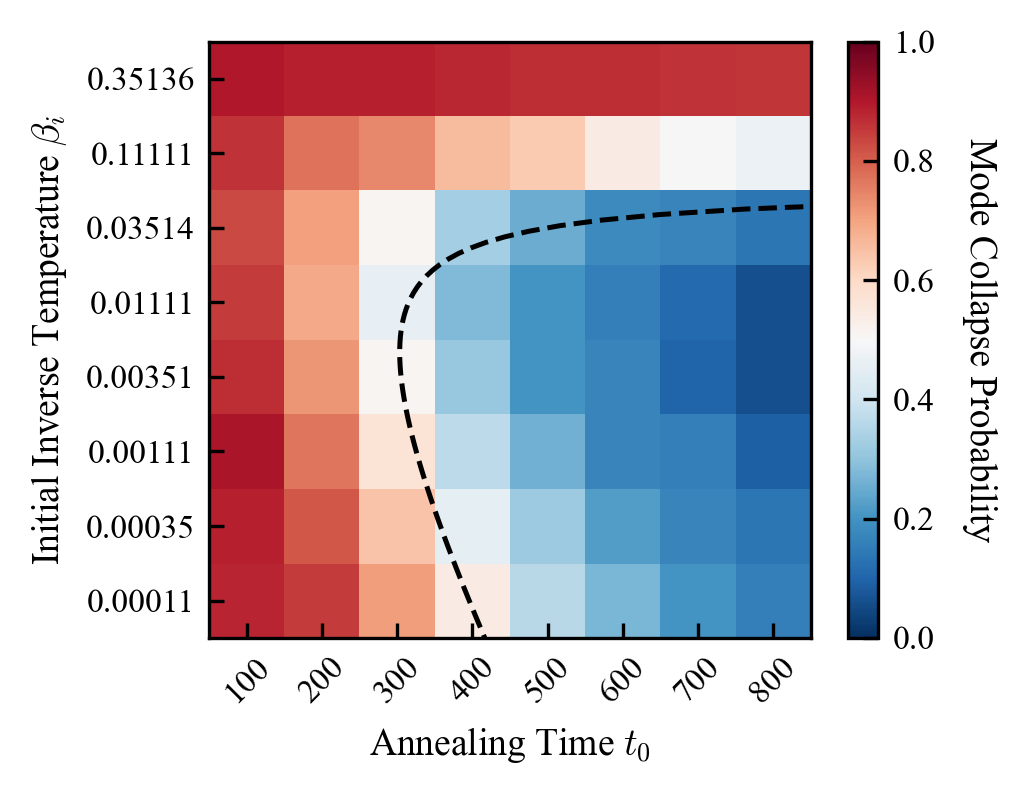

In [30]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman", "DejaVu Serif"], # Prioritize Times for ICML
    "mathtext.fontset": "cm",       # Computer Modern for math
    "font.size": 10,                # Main text size
    "axes.labelsize": 9,           # Axis labels
    "xtick.labelsize": 8,           # Tick labels
    "ytick.labelsize": 8,           # Tick labels
    "legend.fontsize": 8,           # Legend
    "figure.titlesize": 10,
    "xtick.direction": "in",        # Professional touch: ticks point inward
    "ytick.direction": "in",
    "axes.linewidth": 0.8,          # Thinner, cleaner spines
    "figure.dpi": 300               # High resolution for review
})

# Redundant
beta0_values = bimodal_prob_pivot.index
t0_values = bimodal_prob_pivot.columns
prob_matrix = bimodal_prob_pivot.values

# Plotting
fig, ax = plt.subplots(figsize=(3.5, 2.75))
im = ax.imshow(prob_matrix, origin='lower', aspect='auto', cmap='RdBu_r', vmin=0, vmax=1)# cmap : 'magma' or 'RdBu_r'

# Set ticks locations
ax.set_xticks(np.arange(len(t0_values)))
ax.set_yticks(np.arange(len(beta0_values)))
ax.set_xticklabels([f"{int(v)}" for v in t0_values], rotation=45)
ax.set_yticklabels([f"{v:.5f}" for v in beta0_values])

ax.set_xlabel(r'Annealing Time $t_0$')
ax.set_ylabel(r'Initial Inverse Temperature $\beta_i$')

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Mode Collapse Probability', rotation=270, labelpad=15)

#isoprobline
ax.plot((inv_t_list/0.05)/100 -1, (len(beta0_values)-1)*(np.log(beta_list) - np.log(beta0_values[0]))/(np.log(beta0_values[-1]) - np.log(beta0_values[0])), color='black', linestyle='--', linewidth=1.2, label='Theoretical Limit')

ax.set_xlim([-0.5,7.5])
ax.set_ylim([-0.5,7.5])

plt.tight_layout()

# Save with high resolution
#plt.savefig('figures/draft/new_grid_collapse_prob_icml.pdf', bbox_inches='tight', dpi=500)
plt.show()

### Agreement of mode collapse probability estimate with experiment

In [32]:
# Theoretical mode collapse probability values
th_collapse = np.array([[p_collapse(radius, betai, 5e-2*t0, eps, dim) for t0 in t0_values] for betai in betai_values])

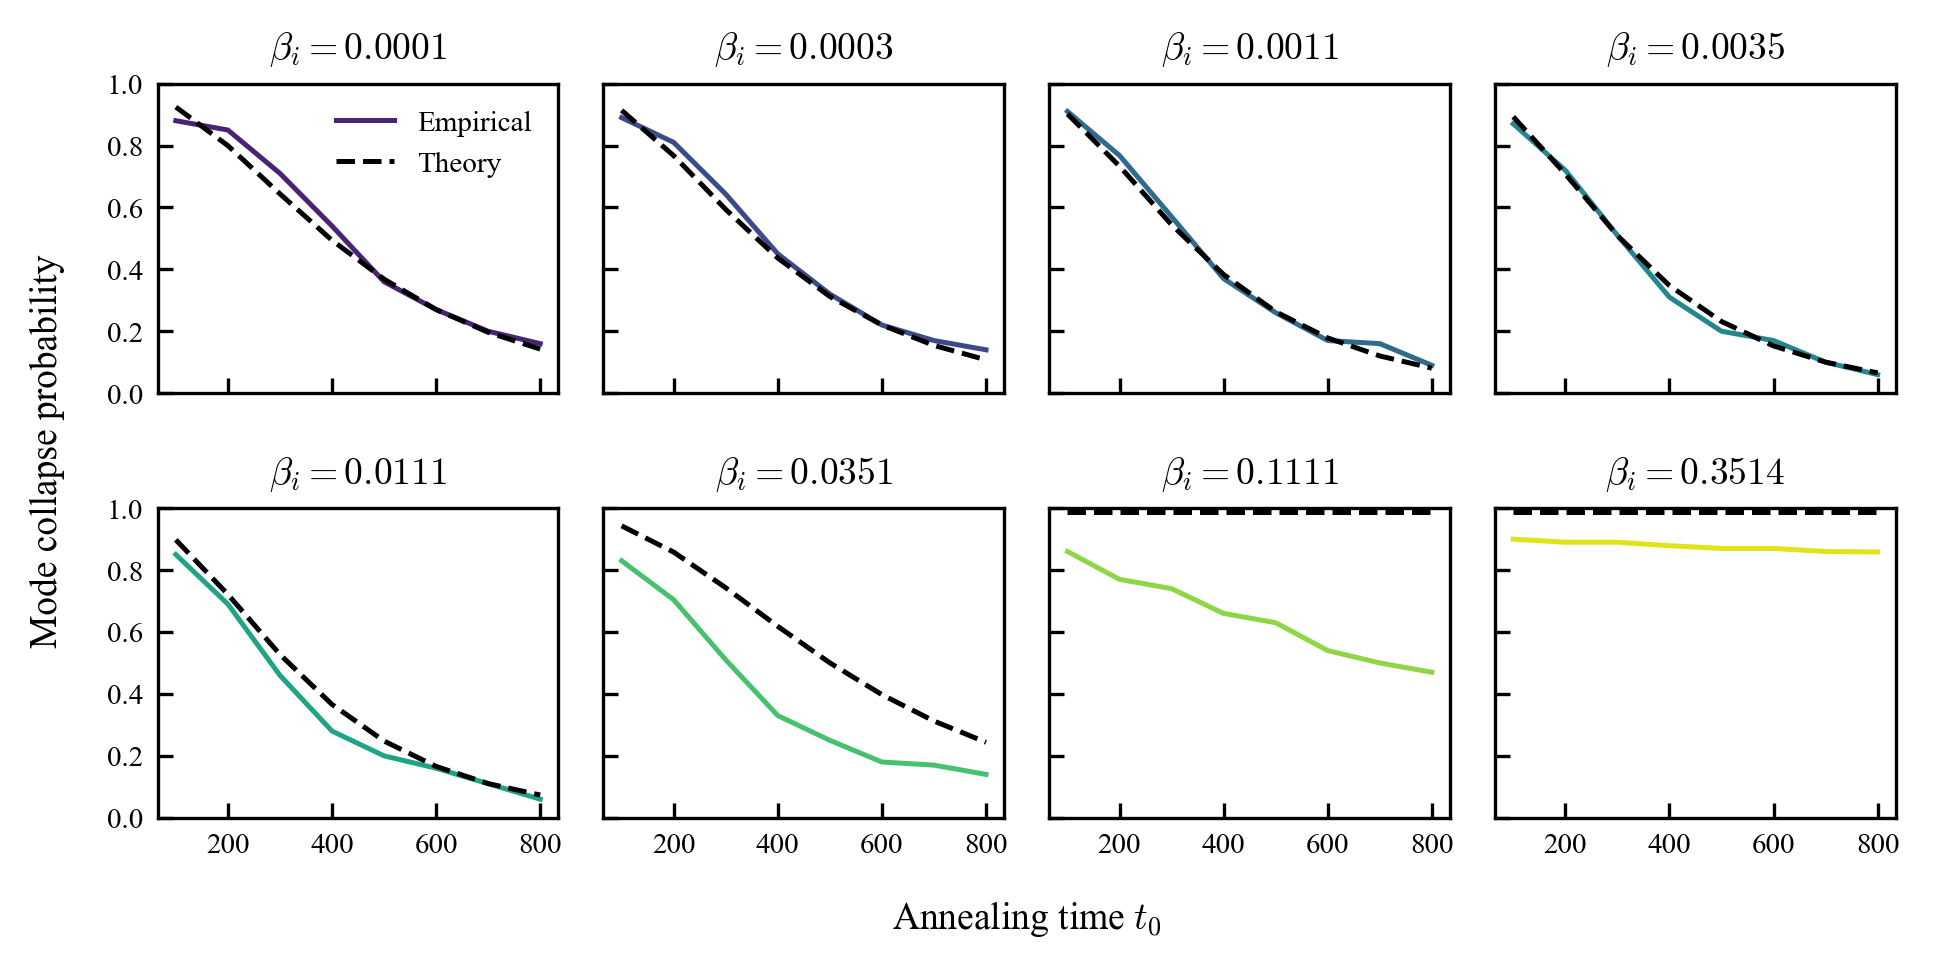

In [33]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": False,         # Grid is helpful in appendix for reading values
    "grid.alpha": 0.3,
    "figure.dpi": 300
})

# Setup: 2 rows, 4 columns
fig, axs = plt.subplots(2, 4, figsize=(6.75, 3.5), sharex=True, sharey=True)
axs = axs.flatten()

# Colors
c_data = '#1f77b4'
c_theory = 'black'
colors = plt.cm.viridis(np.linspace(0.1, 0.95, 8))

for i in range(8):
    ax = axs[i]
    
    # Plot Empirical
    ax.plot(t0_values, prob_matrix[i], color=colors[i], label='Empirical' if i == 0 else "")
    
    # Plot Theory
    ax.plot(t0_values, th_collapse[i], color=c_theory, linestyle='--', label='Theory' if i == 0 else "")
    
    # Title with Beta value
    ax.set_title(fr'$\beta_i = {beta0_values[i]:.4f}$')
    
    # Ticks inside (already set in rcParams, but ensuring here)
    ax.tick_params(direction='in')

    ax.set_ylim([0,1])

# Add Global Legend to the first plot (or outside)
# Putting it in the first plot is standard if it fits
axs[0].legend(loc='best', frameon=False)

# Common Labels
# We use a hidden big frame to set common X and Y labels centered
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
plt.xlabel(r'Annealing time $t_0$', labelpad=10)
plt.ylabel('Mode collapse probability', labelpad=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save
filename = "figures/appendix/collapse_prob_slices.pdf"
#plt.savefig(filename, bbox_inches='tight')
plt.show()

# Mode collapse probability with RealNVP student

Hyperparameters for the target are $d=128$, $R=3$, $w_*=0.8$.

The determine if the student has collapsed, we monitor the variance of the student distribution at convergence.

In [36]:
# Loading the data
exp_name = 'realnvpgrid128/'

res = pd.read_csv('data/'+exp_name+'final_vars1.csv', index_col=0)
res = pd.concat([res, pd.read_csv('data/'+exp_name+'final_vars2.csv', index_col=0)])

res['beta_i'] = np.round(res['beta_i'].values, 6)
res

,exp,beta_i,t0,std,mean
0,10000,1.000000,200,0.994938,3.008732
1,10001,1.000000,200,0.995180,2.998689
2,10002,1.000000,200,1.007223,2.995044
3,10003,1.000000,200,1.011339,2.971715
4,10004,1.000000,200,1.003708,2.984386
...,...,...,...,...,...
9987,29995,0.006248,2000,1.759732,2.606946
9988,29996,0.006248,2000,1.587100,2.705143
9989,29997,0.006248,2000,1.034671,2.969266
9990,29998,0.006248,2000,1.393435,2.810602


In [37]:
print(np.unique(res['beta_i']))

[0.006248 0.011111 0.019759 0.035136 0.062482 0.111111 0.197587 0.351364
 0.624824 1.      ]


In [47]:
### Prob_collapse ###
temp = res.loc[:, ['beta_i', 't0']].copy()
threshold=1.6
temp['prob'] = np.round(res.loc[:, 'std'] < threshold)
prob_collapse = temp.groupby(['beta_i', 't0']).mean()

prob_collapse

prob
beta_i   t0            
0.006248 200   0.840000
         400   0.796954
         600   0.685000
         800   0.590000
         1000  0.735000
...                 ...
1.000000 1200  1.000000
         1400  1.000000
         1600  1.000000
         1800  1.000000
         2000  1.000000

[100 rows x 1 columns]

In [48]:
# Prepare data using a pivot to ensure the grid is correctly aligned
prob_collapse = prob_collapse.reset_index()
realnvp_prob_pivot = prob_collapse.pivot(index='beta_i', columns='t0', values='prob')

betai_values = realnvp_prob_pivot.index
t0_values = realnvp_prob_pivot.columns
prob_matrix = realnvp_prob_pivot.values

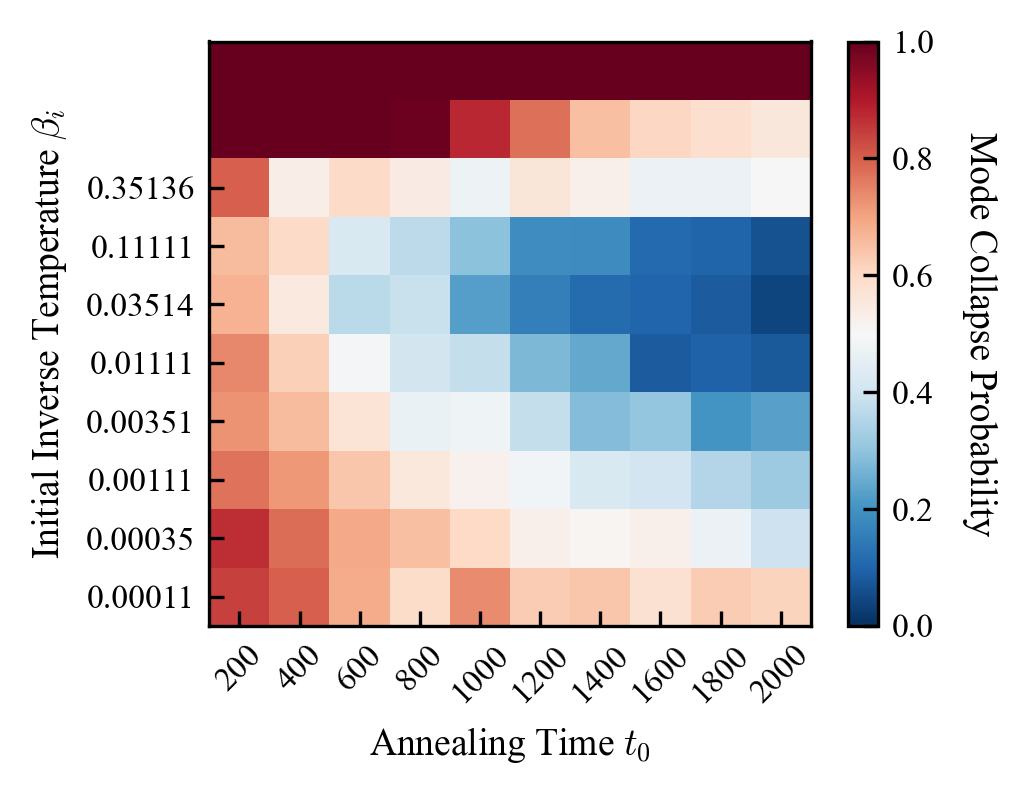

In [49]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",       # Computer Modern for math
    "font.size": 10,                # Main text size
    "axes.labelsize": 9,           # Axis labels
    "xtick.labelsize": 8,           # Tick labels
    "ytick.labelsize": 8,           # Tick labels
    "legend.fontsize": 8,           # Legend
    "figure.titlesize": 10,
    "xtick.direction": "in",        # Professional touch: ticks point inward
    "ytick.direction": "in",
    "axes.linewidth": 0.8,          # Thinner, cleaner spines
    "figure.dpi": 300               # High resolution for review
})

# Plotting
fig, ax = plt.subplots(figsize=(3.5, 2.75))
im = ax.imshow(prob_matrix, origin='lower', aspect='auto', cmap='RdBu_r', vmin=0, vmax=1)# cmap : 'magma' or 'RdBu_r'

# Set ticks locations
ax.set_xticks(np.arange(len(t0_values)))
ax.set_yticks(np.arange(len(beta0_values)))
ax.set_xticklabels([f"{int(v)}" for v in t0_values], rotation=45)
ax.set_yticklabels([f"{v:.5f}" for v in beta0_values])

ax.set_xlabel(r'Annealing Time $t_0$')
ax.set_ylabel(r'Initial Inverse Temperature $\beta_i$')

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Mode Collapse Probability', rotation=270, labelpad=15)

plt.tight_layout()

# Save with high resolution
#plt.savefig('figures/realnvp_grid_collapse_prob.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Mode collapse as a function of the anealing rate

We experimentally verify the theoretical prediction that the mode collapse probability only depends on the annealing rate when the initial temperature is high enough.

In [54]:
# Theoretical mode collapse probability for high initial temperatures
t0_list = np.linspace(200,2000,200)
beta_i = 1e-5/radius**2

p_collapse_asymptotic = np.array([p_collapse(radius, beta_i, 5e-2*t0, eps, dim) for t0 in t0_list])

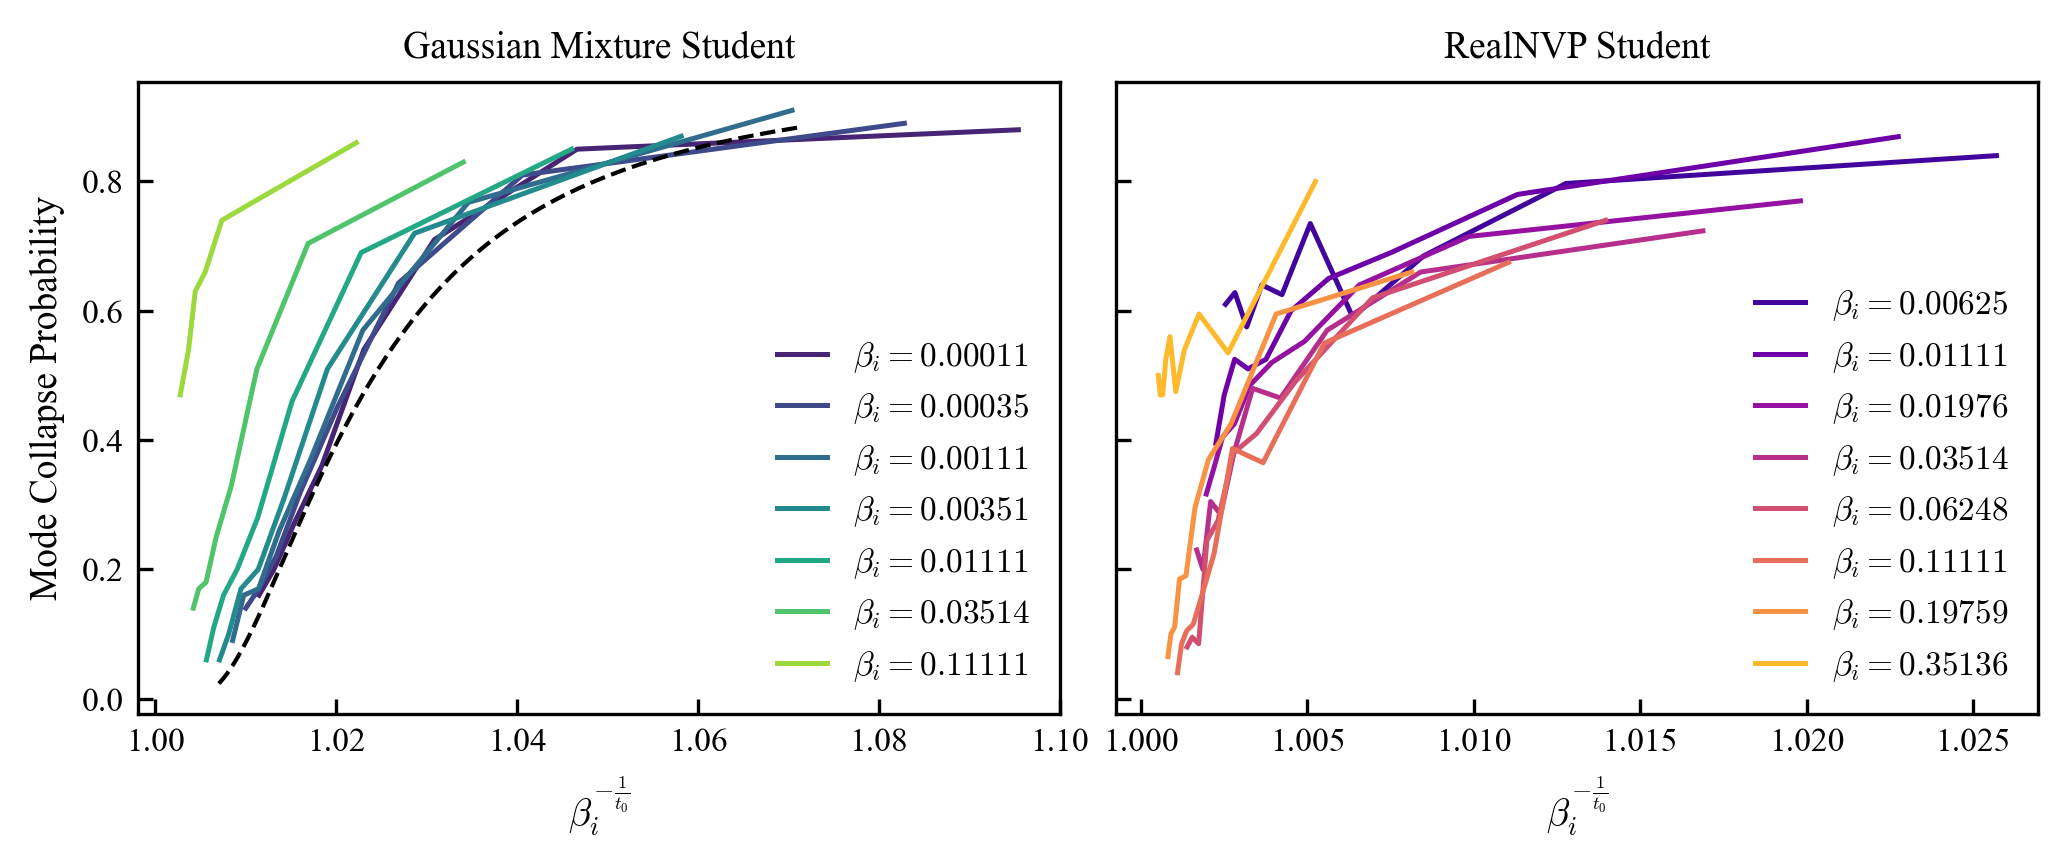

In [53]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",      # LaTeX-style math font
    "font.size": 10,                # Base font size
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "lines.linewidth": 1.2,
    "xtick.direction": "in",       # Ticks pointing inwards
    "ytick.direction": "in",
    "axes.grid": False,            # Usually cleaner without grid for this type of plot
    "figure.dpi": 300
})


fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(6.75, 2.75), sharey=True)


###################
#Bimodal gaussians#
###################

beta0_values = bimodal_prob_pivot.index
t0_values = bimodal_prob_pivot.columns
prob_matrix = bimodal_prob_pivot.values

# Filter valid betas first to determine how many colors we need
valid_indices = [i for i, b in enumerate(beta0_values) if b < 0.3] # 1/9/3 approx 0.037
num_curves = len(valid_indices)

# Generate a progressive colormap (Viridis)
colors = plt.cm.viridis(np.linspace(0.1, 0.85, num_curves))

# --- Plotting Loop ---
for idx, color_idx in enumerate(valid_indices):
    beta = beta0_values[color_idx]
    prob = prob_matrix[color_idx]
    
    # X-axis transformation
    x_vals = beta**(-1/t0_values)
    
    # Plot with specific color
    ax1.plot(x_vals, prob, color=colors[idx], label=fr'$\beta_i = {beta:.5f}$')

# --- Asymptotic Theoretical Limit ---
x_theory = beta_i**(-1/t0_list)
ax1.plot(x_theory, p_collapse_asymptotic, color='black', linewidth=1.0, linestyle='--', zorder=5)

# --- Labels & Formatting ---
ax1.set_xlabel(r'$\beta_i^{-\frac{1}{t_0}}$') # Nicely formatted fraction
ax1.set_ylabel('Mode Collapse Probability')

ax1.legend(loc='best', frameon=False, handlelength=1.5)
ax1.set_title('Gaussian Mixture Student')


#########
#RealNVP#
#########

beta0_values = realnvp_prob_pivot.index
t0_values = realnvp_prob_pivot.columns
prob_matrix = realnvp_prob_pivot.values

# Filter valid betas first to determine how many colors we need
valid_indices = [i for i, b in enumerate(beta0_values) if b < 0.6] # 1/9/3 approx 0.037
num_curves = len(valid_indices)

# Generate a progressive colormap (Viridis)
colors = plt.cm.plasma(np.linspace(0.1, 0.85, num_curves))

# --- Plotting Loop ---
for idx, color_idx in enumerate(valid_indices):
    beta = beta0_values[color_idx]
    prob = prob_matrix[color_idx]
    
    # X-axis is the annealing rate
    x_vals = beta**(-1/t0_values)
    
    # Plot with specific color
    ax2.plot(x_vals, prob, color=colors[idx], label=fr'$\beta_i = {beta:.5f}$')


# --- Labels & Formatting ---
ax2.set_xlabel(r'$\beta_i^{-\frac{1}{t_0}}$') # Nicely formatted fraction

ax2.legend(loc='best', frameon=False, handlelength=1.5)
ax2.set_title('RealNVP Student')


plt.tight_layout(pad=0.2)

# Save
#plt.savefig("figures/summary_probability_collapse.pdf", bbox_inches='tight')

plt.show()